In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from src.config import *

# Importing Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

plt.style.use("default")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", 100)

# Loading Dataset

In [3]:
df = pd.read_parquet(PROCESSED_DATA_DIR / "breast_cancer.parquet")

print("Dataset loaded.")
print("Shape:", df.shape)

Dataset loaded.
Shape: (130, 54676)


# Dataset Inspection

In [4]:
df.head()

,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,1431_at,1438_at,1487_at,1494_f_at,1552256_a_at,1552257_a_at,1552258_at,1552261_at,1552263_at,1552264_a_at,1552266_at,1552269_at,1552271_at,1552272_a_at,1552274_at,1552275_s_at,1552276_a_at,1552277_a_at,1552278_a_at,1552279_a_at,1552280_at,1552281_at,1552283_s_at,1552286_at,1552287_s_at,1552288_at,1552289_a_at,1552291_at,1552293_at,1552295_a_at,1552296_at,1552299_at,1552301_a_at,1552302_at,1552303_a_at,1552304_at,1552306_at,1552307_a_at,1552309_a_at,1552310_at,...,AFFX-HSAC07/X00351_3_at,AFFX-HSAC07/X00351_5_at,AFFX-HSAC07/X00351_M_at,AFFX-hum_alu_at,AFFX-HUMGAPDH/M33197_3_at,AFFX-HUMGAPDH/M33197_5_at,AFFX-HUMGAPDH/M33197_M_at,AFFX-HUMISGF3A/M97935_3_at,AFFX-HUMISGF3A/M97935_5_at,AFFX-HUMISGF3A/M97935_MA_at,AFFX-HUMISGF3A/M97935_MB_at,AFFX-HUMRGE/M10098_3_at,AFFX-HUMRGE/M10098_5_at,AFFX-HUMRGE/M10098_M_at,AFFX-LysX-3_at,AFFX-LysX-5_at,AFFX-LysX-M_at,AFFX-M27830_3_at,AFFX-M27830_5_at,AFFX-M27830_M_at,AFFX-PheX-3_at,AFFX-PheX-5_at,AFFX-PheX-M_at,AFFX-r2-Bs-dap-3_at,AFFX-r2-Bs-dap-5_at,AFFX-r2-Bs-dap-M_at,AFFX-r2-Bs-lys-3_at,AFFX-r2-Bs-lys-5_at,AFFX-r2-Bs-lys-M_at,AFFX-r2-Bs-phe-3_at,AFFX-r2-Bs-phe-5_at,AFFX-r2-Bs-phe-M_at,AFFX-r2-Bs-thr-3_s_at,AFFX-r2-Bs-thr-5_s_at,AFFX-r2-Bs-thr-M_s_at,AFFX-r2-Ec-bioB-3_at,AFFX-r2-Ec-bioB-5_at,AFFX-r2-Ec-bioB-M_at,AFFX-r2-Ec-bioC-3_at,AFFX-r2-Ec-bioC-5_at,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,basal,9.850040,8.097927,6.424728,7.353027,3.029122,6.880079,4.963740,4.408328,8.870780,3.278896,7.317273,6.941792,4.753893,9.689422,9.529577,4.416768,4.061347,6.468291,8.671009,3.766666,3.711459,5.076329,4.442042,6.741298,5.627442,5.516712,8.107137,4.956239,5.791278,3.569233,5.687476,4.152096,4.906925,8.206707,4.463950,5.186044,5.942088,4.191142,7.413500,3.281950,4.346253,3.883254,5.143185,5.953880,3.809546,4.903795,6.163062,5.960296,6.503104,...,13.617425,13.334688,13.611892,14.617621,13.620367,13.816580,13.953181,10.944267,8.018416,9.566412,9.015007,12.050521,14.750905,13.359472,5.576968,3.606041,4.481027,5.509117,10.544533,11.200692,5.932332,4.253946,5.052680,7.782348,7.056759,7.787824,4.784976,3.943038,3.903069,6.119248,4.461984,4.752744,6.761262,5.298281,6.048960,8.292124,8.225292,8.333854,9.854639,9.823276,12.229711,11.852955,13.658701,13.477698,6.265781,5.016196,4.901594,2.966657,3.508495,3.301999
1,basal,9.861358,8.212222,7.062593,7.685578,3.149468,7.542283,5.129607,4.584418,7.767646,3.589636,8.768128,7.567034,4.859823,8.459353,8.973671,4.503730,5.390424,6.756707,8.105795,4.651541,3.935309,5.228763,4.454780,6.468014,5.798596,5.306064,7.505800,4.636866,5.898319,3.749061,5.582313,4.449042,5.871074,7.242601,3.938327,4.378953,6.294126,4.058221,6.799876,3.004077,5.170231,3.915350,5.618675,6.103758,3.468310,3.805643,5.059153,7.665774,6.230720,...,13.724468,13.150683,13.449886,14.718935,13.650388,13.720148,13.877806,11.397179,8.665182,10.400596,9.371175,8.264719,9.938356,9.507651,6.103961,3.983088,4.742306,5.424171,8.881772,11.148811,6.330691,4.755615,5.474167,8.542725,7.617779,8.237535,5.209694,3.939264,4.553344,6.017351,5.425393,4.957181,7.405313,5.615380,6.617585,8.225366,8.409790,8.499343,10.061910,9.796947,12.178531,11.809408,13.750086,13.470146,6.771852,5.291005,5.405838,2.934763,3.687666,3.064299
2,basal,10.103478,8.936137,5.735970,7.687822,3.125932,6.562369,4.813449,4.425195,9.417956,3.552253,7.945086,7.238284,4.872635,9.367521,9.133688,4.358608,4.445164,5.476936,8.752114,3.546838,4.263868,5.509159,4.624205,7.103216,6.641263,5.141131,7.072525,4.728196,6.233648,3.766725,6.008163,4.191391,5.717077,7.809222,4.108028,5.012451,7.258626,4.330997,6.901454,4.032173,4.203554,4.133018,4.262457,4.463875,3.533392,4.019280,5.058569,5.264810,5.795663,...,13.484744,13.095263,13.307587,14.560461,14.012596,14.186929,14.372375,10.853230,8.196331,9.569713,8.842430,10.241912,13.605902,11.784268,5.8530

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Columns: 54676 entries, type to AFFX-TrpnX-M_at
dtypes: float32(54675), object(1)
memory usage: 27.1+ MB


## Identifying Target Column

In [6]:
target_col = "type"

## Identifying Class Distribution

In [7]:
class_counts = df[target_col].value_counts()

print(class_counts)

type
basal        41
HER          30
luminal_B    30
luminal_A    29
Name: count, dtype: int64


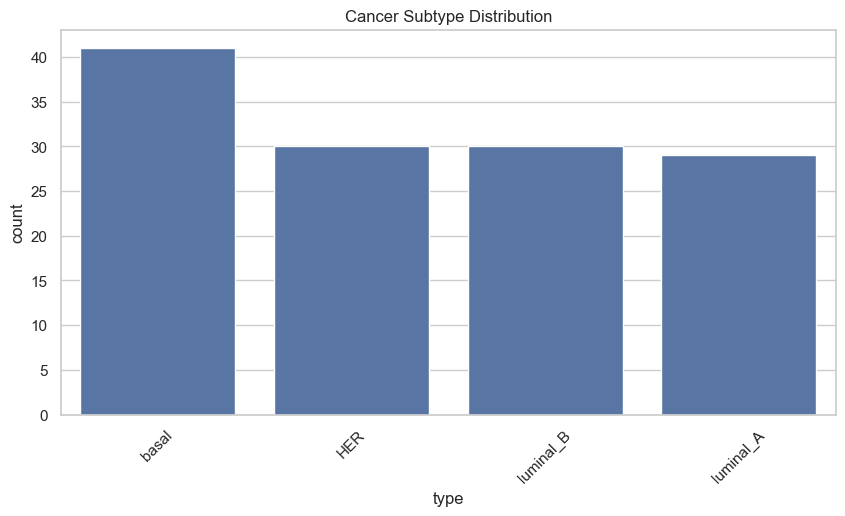

In [8]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x=target_col,
    order=class_counts.index
)

plt.title("Cancer Subtype Distribution")
plt.xticks(rotation=45)
plt.show()

## Missing Values

In [9]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

## Separating Features & labels

In [10]:
X = df.drop(columns=[target_col])

y = df[target_col]

print("Features shape:", X.shape)
print("Labels shape:", y.shape)

Features shape: (130, 54675)
Labels shape: (130,)


## Gene Statistics

In [11]:
X.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
1007_s_at,130.0,10.392065,0.557843,7.505488,10.113618,10.446867,10.758311,11.675109
1053_at,130.0,7.569988,0.559904,6.183528,7.192599,7.508395,7.933492,8.936137
117_at,130.0,6.363503,0.571551,5.048510,5.965899,6.316629,6.675465,8.364749
121_at,130.0,7.299507,0.286135,6.632206,7.100138,7.294114,7.475289,8.289417
1255_g_at,130.0,3.172048,0.156322,2.760583,3.068891,3.181398,3.264093,3.611630


### Gene Expression Distribution

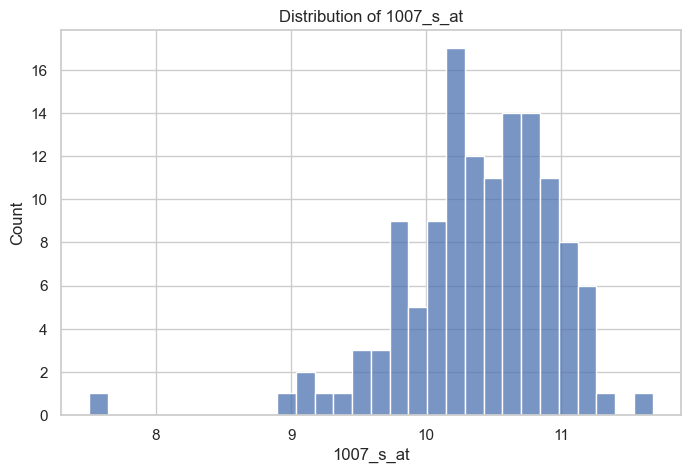

In [12]:
gene_1007_s_at = X.columns[0]

plt.figure(figsize=(8,5))

sns.histplot(X[gene_1007_s_at], bins=30)

plt.title(f"Distribution of {gene_1007_s_at}")
plt.show()

### Variance Analysis

In [13]:
gene_variances = X.var().sort_values(ascending=False)

gene_variances.head()

206378_at    17.065277
228241_at    13.925416
205916_at    11.682548
209173_at    11.042471
237339_at    10.922509
dtype: float32

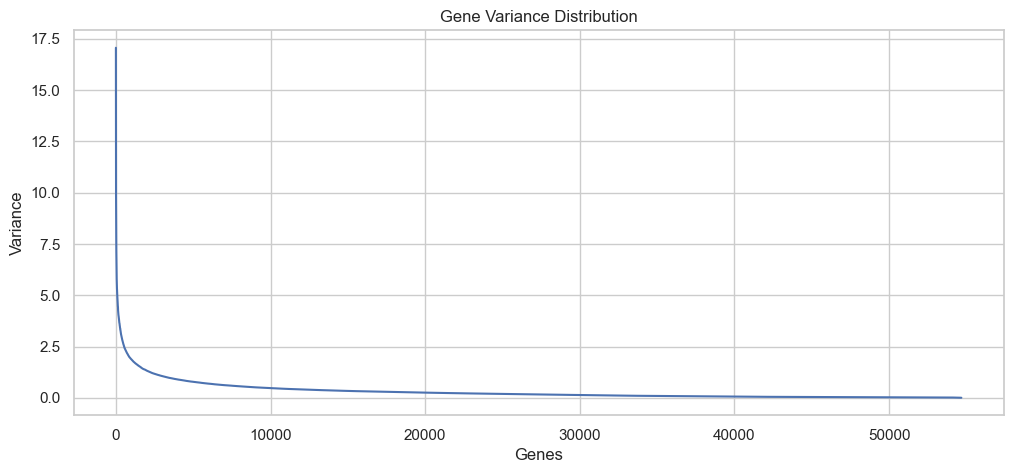

In [14]:
plt.figure(figsize=(12,5))

plt.plot(gene_variances.values)

plt.title("Gene Variance Distribution")
plt.xlabel("Genes")
plt.ylabel("Variance")

plt.show()

### Correlation Exploration

In [15]:
sample_genes = X.columns[:21]

corr_matrix = X[sample_genes].corr()


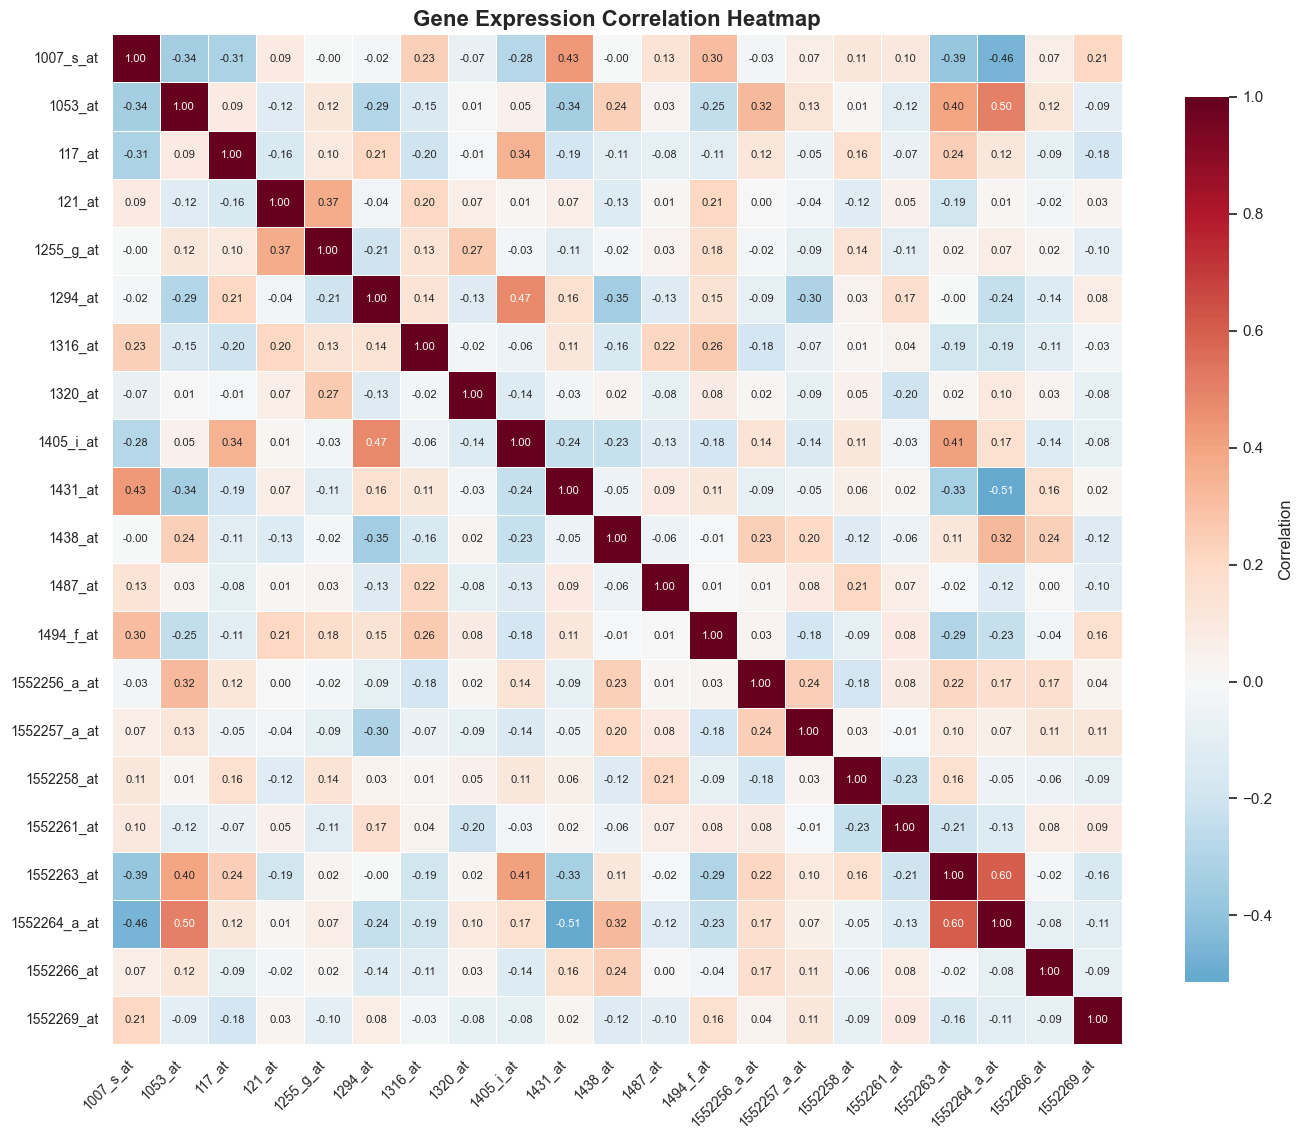

In [16]:
plt.figure(figsize=(14, 12))

sns.heatmap(
    corr_matrix,
    annot=True,                 # show correlation values
    fmt=".2f",
    cmap="RdBu_r",              # better scientific colormap
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Correlation"},
    annot_kws={"size": 8}
)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.title(
    "Gene Expression Correlation Heatmap",
    fontsize=16,
    weight="bold"
)

plt.tight_layout()
plt.show()

## PCA

In [17]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

In [18]:
explained_var = pca.explained_variance_ratio_
print("Explained variance:", explained_var)

Explained variance: [0.17040002 0.05760496]


In [19]:
pca_df = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "Subtype": y
})

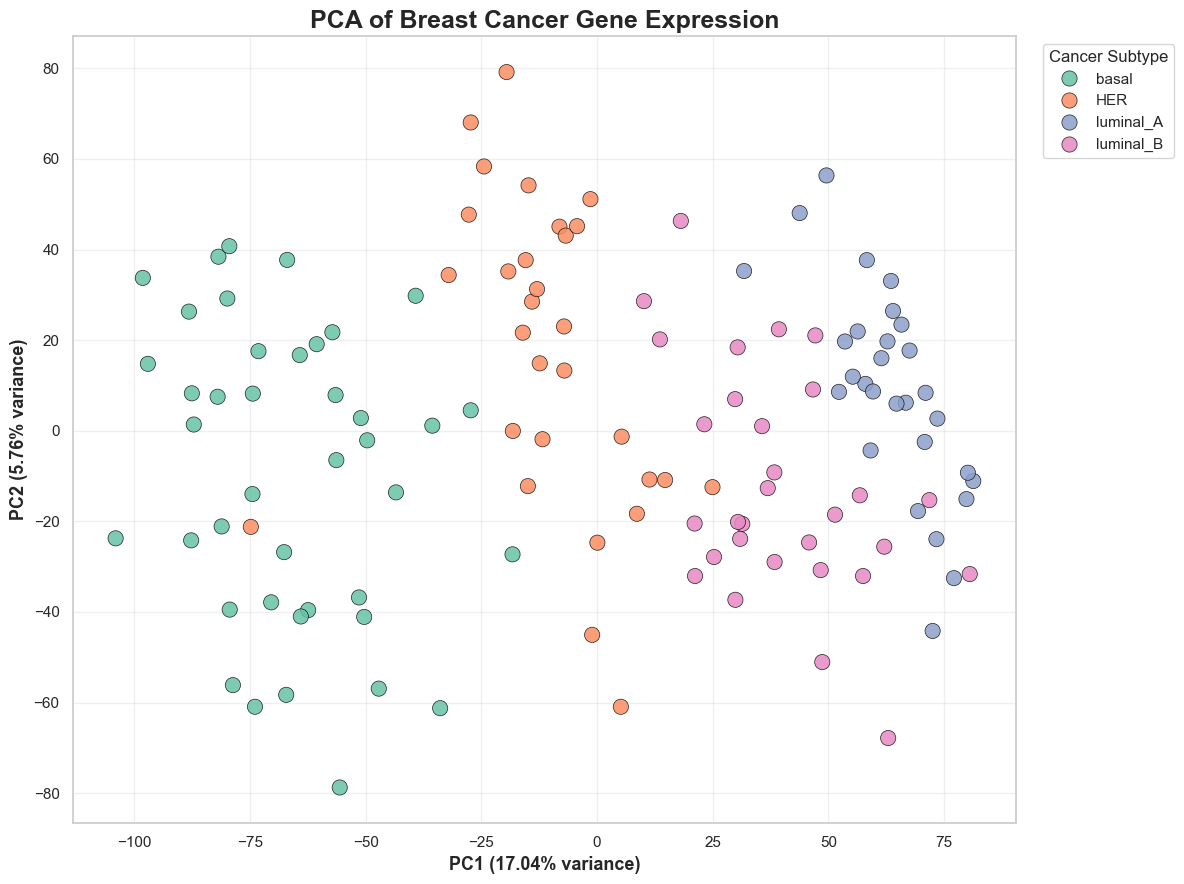

In [20]:
plt.figure(figsize=(12, 9))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Subtype",
    palette="Set2",
    s=120,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.5
)

plt.xlabel(
    f"PC1 ({explained_var[0]*100:.2f}% variance)",
    fontsize=13,
    weight="bold"
)

plt.ylabel(
    f"PC2 ({explained_var[1]*100:.2f}% variance)",
    fontsize=13,
    weight="bold"
)

plt.title(
    "PCA of Breast Cancer Gene Expression",
    fontsize=18,
    weight="bold"
)

plt.grid(alpha=0.3)

plt.legend(
    title="Cancer Subtype",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

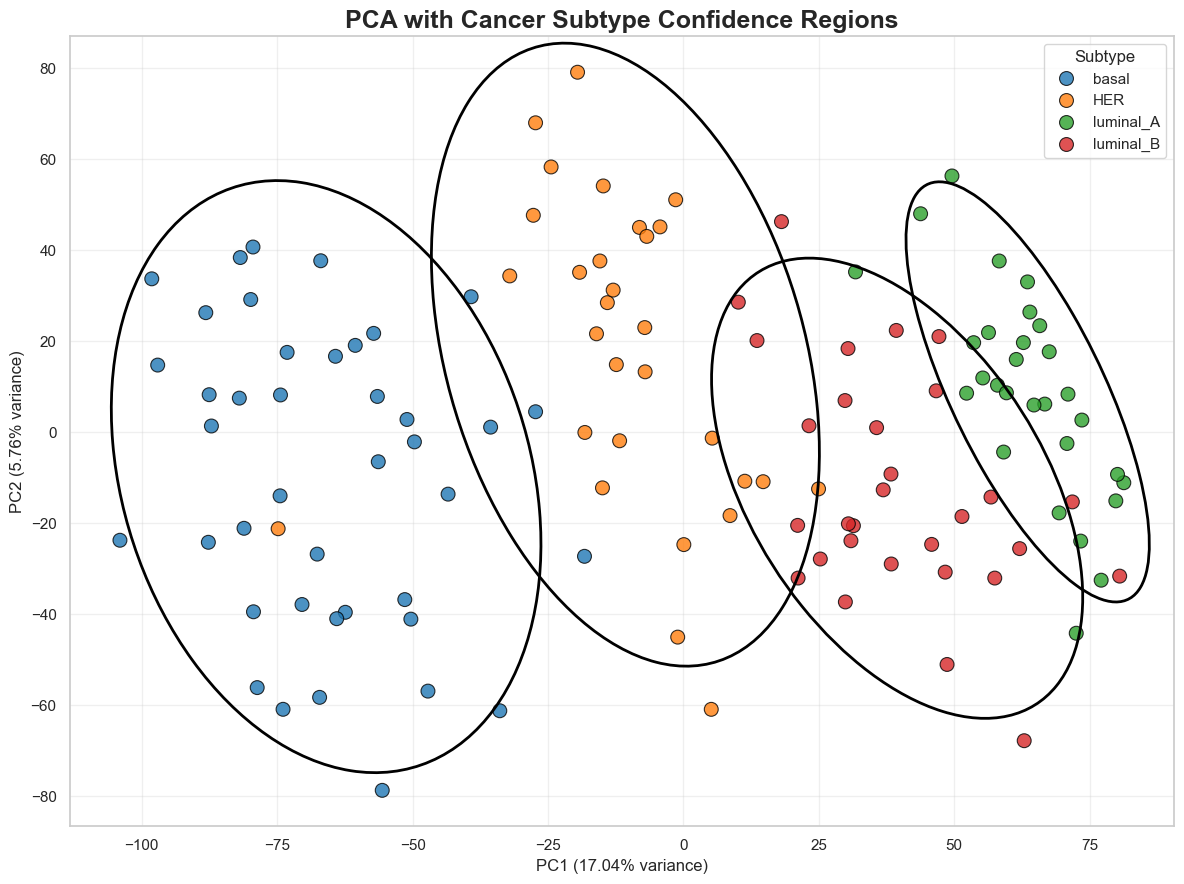

In [21]:
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

def confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])

    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)

    ellipse = Ellipse(
        (0, 0),
        width=ell_radius_x * 2,
        height=ell_radius_y * 2,
        fill=False,
        **kwargs
    )

    scale_x = np.sqrt(cov[0, 0]) * n_std
    mean_x = np.mean(x)

    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_y = np.mean(y)

    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)

    ellipse.set_transform(transf + ax.transData)

    return ax.add_patch(ellipse)

# Plot
fig, ax = plt.subplots(figsize=(12, 9))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Subtype",
    palette="tab10",
    s=100,
    alpha=0.8,
    edgecolor="black",
    ax=ax
)

# Add ellipses
for subtype in pca_df["Subtype"].unique():
    subset = pca_df[pca_df["Subtype"] == subtype]

    confidence_ellipse(
        subset["PC1"],
        subset["PC2"],
        ax,
        edgecolor="black",
        linewidth=2
    )

plt.title(
    "PCA with Cancer Subtype Confidence Regions",
    fontsize=18,
    weight="bold"
)

plt.xlabel(f"PC1 ({explained_var[0]*100:.2f}% variance)")
plt.ylabel(f"PC2 ({explained_var[1]*100:.2f}% variance)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

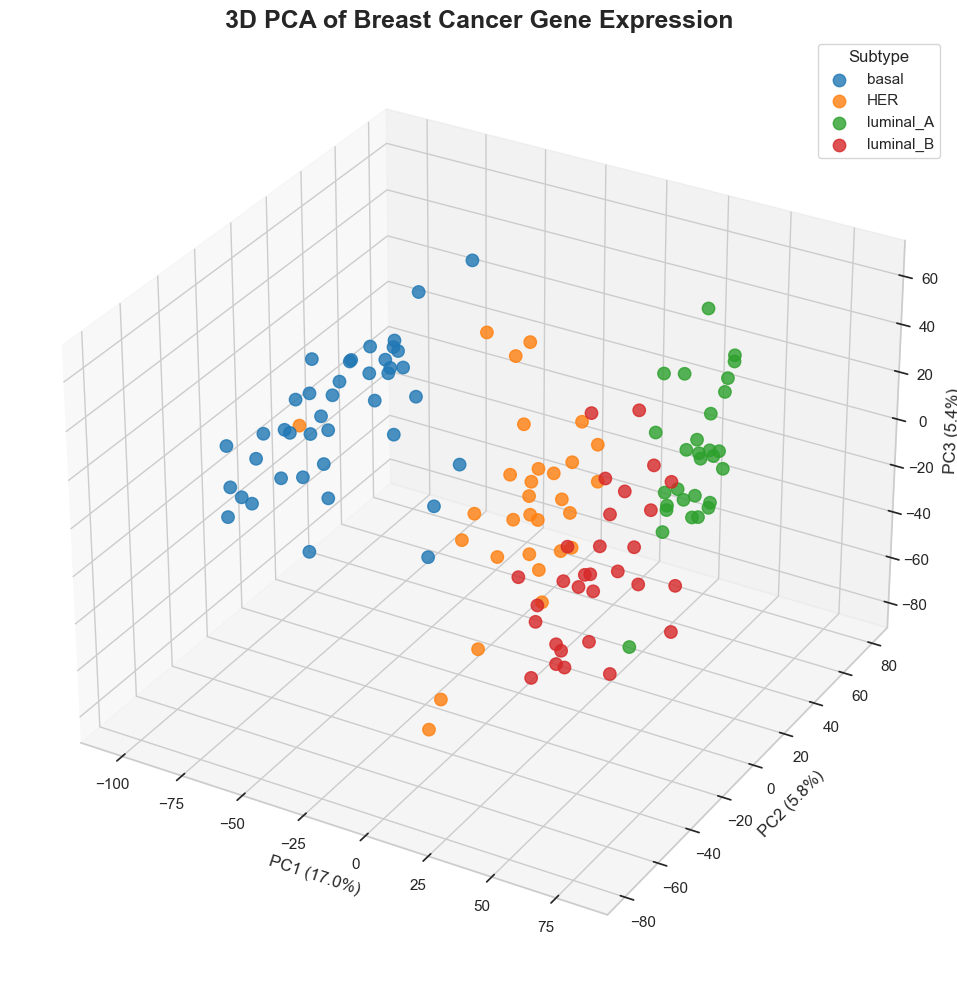

In [22]:
from mpl_toolkits.mplot3d import Axes3D

# PCA with 3 components
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

explained_var = pca.explained_variance_ratio_

pca_df = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "PC3": X_pca[:,2],
    "Subtype": y
})

fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(111, projection='3d')

subtypes = pca_df["Subtype"].unique()
colors = sns.color_palette("tab10", len(subtypes))

for subtype, color in zip(subtypes, colors):
    subset = pca_df[pca_df["Subtype"] == subtype]

    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        subset["PC3"],
        label=subtype,
        s=80,
        alpha=0.8,
        color=color
    )

ax.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({explained_var[2]*100:.1f}%)')

ax.set_title(
    "3D PCA of Breast Cancer Gene Expression",
    fontsize=18,
    weight="bold"
)

ax.legend(title="Subtype")

plt.tight_layout()
plt.show()

# UMAP / t-SNE Analysis

In [23]:
import umap.umap_ as umap

# -----------------------------
# Select top variable genes
# -----------------------------
top_var_genes = X.var().sort_values(
    ascending=False
).head(500).index

X_selected = X[top_var_genes]
# -----------------------------
# PCA preprocessing (denoising)
# -----------------------------
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# -----------------------------
# UMAP
# -----------------------------
umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='euclidean',
    random_state=42
)

X_umap = umap_model.fit_transform(X_pca)

# -----------------------------
# DataFrame
# -----------------------------
umap_df = pd.DataFrame({
    "UMAP1": X_umap[:, 0],
    "UMAP2": X_umap[:, 1],
    "Subtype": y
})

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12, 9))

sns.scatterplot(
    data=umap_df,
    x="UMAP1",
    y="UMAP2",
    hue="Subtype",
    palette="tab10",
    s=120,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.4
)

plt.title(
    "UMAP of Breast Cancer Gene Expression",
    fontsize=18,
    weight="bold"
)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")

plt.legend(
    title="Subtype",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'umap'

In [ ]:
from sklearn.manifold import TSNE

# t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42,
    init='pca'
)

X_tsne = tsne.fit_transform(X_pca)

# DataFrame
tsne_df = pd.DataFrame({
    "TSNE1": X_tsne[:, 0],
    "TSNE2": X_tsne[:, 1],
    "Subtype": y
})

# Plot
plt.figure(figsize=(12, 9))

sns.scatterplot(
    data=tsne_df,
    x="TSNE1",
    y="TSNE2",
    hue="Subtype",
    palette="Set2",
    s=120,
    alpha=0.85,
    edgecolor="black"
)

plt.title(
    "t-SNE of Breast Cancer Gene Expression",
    fontsize=18,
    weight="bold"
)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.legend(
    title="Subtype",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# Saving Artifacts

In [ ]:
pca_df.to_parquet(
    PROCESSED_DATA_DIR / "pca_2d.parquet",
    index=False
)
print("Done")

Done
